# Data Processing Code

Name: Matthew Vu  
Due Date: 12/03/2023

## Import Libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Clean the SOL pass rate and median household income datasets to get final dataset

In [2]:
# load in the raw SOL performance dataset
sol_data = pd.read_csv("Datasets/Raw Data/sol_stats.csv")

In [3]:
# show raw SOL performance dataset
sol_data

,School Year,Division Number,Division Name,Subject,Test Level,Test Source,Pass Rate
0,2014-2015,1,Accomack County,English:Reading,Grade 3,SOL,61.08
1,2014-2015,1,Accomack County,Mathematics,Grade 3,SOL,64.65
2,2014-2015,1,Accomack County,English:Reading,Grade 4,SOL,66.57
3,2014-2015,1,Accomack County,Mathematics,Grade 4,SOL,76.16
4,2014-2015,1,Accomack County,English:Reading,Grade 5,SOL,70.45
...,...,...,...,...,...,...,...
7890,2018-2019,98,York County,Mathematics,Grade 6,SOL,92.25
7891,2018-2019,98,York County,English:Reading,Grade 7,SOL,89.04
7892,2018-2019,98,York County,Mathematics,Grade 7,SOL,77.66
7893,2018-2019,98,York County,English:Reading,Grade 8,SOL,81.43


In [4]:
# show raw SOL data types
sol_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7895 entries, 0 to 7894
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   School Year      7895 non-null   object
 1   Division Number  7895 non-null   int64 
 2   Division Name    7895 non-null   object
 3   Subject          7895 non-null   object
 4   Test Level       7895 non-null   object
 5   Test Source      7895 non-null   object
 6   Pass Rate        7895 non-null   object
dtypes: int64(1), object(6)
memory usage: 431.9+ KB


In [5]:
# rename columns to make them easier to work with
sol_data["school_year"] = sol_data["School Year"]
sol_data["division_number"] = sol_data["Division Number"]
sol_data["division_name"] = sol_data["Division Name"]
sol_data["subject"] = sol_data["Subject"]
sol_data["grade_level"] = sol_data["Test Level"]
# sol_data["total_count"] = sol_data["Total Count"]
sol_data["pass_rate"] = sol_data["Pass Rate"]

In [6]:
# select only relevant columns
sol_data_reduced = sol_data[["school_year", "division_name", "subject", "grade_level", "pass_rate"]].copy()

In [7]:
# show dataset
sol_data_reduced

,school_year,division_name,subject,grade_level,pass_rate
0,2014-2015,Accomack County,English:Reading,Grade 3,61.08
1,2014-2015,Accomack County,Mathematics,Grade 3,64.65
2,2014-2015,Accomack County,English:Reading,Grade 4,66.57
3,2014-2015,Accomack County,Mathematics,Grade 4,76.16
4,2014-2015,Accomack County,English:Reading,Grade 5,70.45
...,...,...,...,...,...
7890,2018-2019,York County,Mathematics,Grade 6,92.25
7891,2018-2019,York County,English:Reading,Grade 7,89.04
7892,2018-2019,York County,Mathematics,Grade 7,77.66
7893,2018-2019,York County,English:Reading,Grade 8,81.43


In [8]:
# change all string data type to lower case and strip away leading and trailing whitespace
sol_data_reduced["school_year"] = sol_data_reduced["school_year"].str.lower().str.strip()
sol_data_reduced["division_name"] = sol_data_reduced["division_name"].str.lower().str.strip()
sol_data_reduced["subject"] = sol_data_reduced["subject"].str.lower().str.strip()
sol_data_reduced["grade_level"] = sol_data_reduced["grade_level"].str.lower().str.strip()

In [9]:
# display
sol_data_reduced

,school_year,division_name,subject,grade_level,pass_rate
0,2014-2015,accomack county,english:reading,grade 3,61.08
1,2014-2015,accomack county,mathematics,grade 3,64.65
2,2014-2015,accomack county,english:reading,grade 4,66.57
3,2014-2015,accomack county,mathematics,grade 4,76.16
4,2014-2015,accomack county,english:reading,grade 5,70.45
...,...,...,...,...,...
7890,2018-2019,york county,mathematics,grade 6,92.25
7891,2018-2019,york county,english:reading,grade 7,89.04
7892,2018-2019,york county,mathematics,grade 7,77.66
7893,2018-2019,york county,english:reading,grade 8,81.43


In [10]:
# view
sol_data_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7895 entries, 0 to 7894
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   school_year    7895 non-null   object
 1   division_name  7895 non-null   object
 2   subject        7895 non-null   object
 3   grade_level    7895 non-null   object
 4   pass_rate      7895 non-null   object
dtypes: object(5)
memory usage: 308.5+ KB


In [11]:
# change values "<50" and ">50" to NaN because 
# "<50" occurs when there are fewer than 20 students
# in the group and the pass rate is less than 50%
# ">50" occurs when there are fewer than 10 students in the 
# group and the pass rate is more than 50%.
# These both indicate that there are too few students in the group
# to obtain a meaningful pass rate.
sol_data_reduced.loc[:, "pass_rate"] = sol_data_reduced.replace(["<50", ">50"], np.nan)

In [12]:
# change the pass rate column to a floating data type
# sol_data_reduced["total_count"] = pd.to_numeric(sol_data_reduced["total_count"], errors='coerce')
sol_data_reduced['pass_rate'] = pd.to_numeric(sol_data_reduced['pass_rate'], errors='coerce')

In [13]:
# create a new column that will store the year that the median household income
# was recorded for
sol_data_reduced['med_income_year'] = sol_data_reduced['school_year'].str.split('-').str[0].astype(int)

In [14]:
# extract grade level number
sol_data_reduced['grade_level'] = sol_data_reduced['grade_level'].str.split(' ').str[1].astype(int)

In [15]:
# show dataset
sol_data_reduced

,school_year,division_name,subject,grade_level,pass_rate,med_income_year
0,2014-2015,accomack county,english:reading,3,61.08,2014
1,2014-2015,accomack county,mathematics,3,64.65,2014
2,2014-2015,accomack county,english:reading,4,66.57,2014
3,2014-2015,accomack county,mathematics,4,76.16,2014
4,2014-2015,accomack county,english:reading,5,70.45,2014
...,...,...,...,...,...,...
7890,2018-2019,york county,mathematics,6,92.25,2018
7891,2018-2019,york county,english:reading,7,89.04,2018
7892,2018-2019,york county,mathematics,7,77.66,2018
7893,2018-2019,york county,english:reading,8,81.43,2018


In [16]:
# show dataset types
sol_data_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7895 entries, 0 to 7894
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school_year      7895 non-null   object 
 1   division_name    7895 non-null   object 
 2   subject          7895 non-null   object 
 3   grade_level      7895 non-null   int32  
 4   pass_rate        7857 non-null   float64
 5   med_income_year  7895 non-null   int32  
dtypes: float64(1), int32(2), object(3)
memory usage: 308.5+ KB


In [17]:
# load in all the raw median household income datasets
# from 2014 to 2018
# note, we assume that the median household income for a
# school division in a particular school year is equal to 
# their county or city's median household income starting year
# in their academic school year
# for example, the 2014-2015 school year for Fairfax County Public Schools will be assigned 
# the 2014 median household income for Fairfax County
income2014 = pd.read_csv("Datasets/Raw Data/income_data/ACSST5Y2014.S1901-Data.csv")
income2015 = pd.read_csv("Datasets/Raw Data/income_data/ACSST5Y2015.S1901-Data.csv")
income2016 = pd.read_csv("Datasets/Raw Data/income_data/ACSST5Y2016.S1901-Data.csv")
income2017 = pd.read_csv("Datasets/Raw Data/income_data/ACSST5Y2017.S1901-Data.csv")
income2018 = pd.read_csv("Datasets/Raw Data/income_data/ACSST5Y2018.S1901-Data.csv")


In [18]:
# view raw datasets
income2014

,GEO_ID,NAME,S1901_C01_001E,S1901_C01_001M,S1901_C02_001E,S1901_C02_001M,S1901_C03_001E,S1901_C03_001M,S1901_C04_001E,S1901_C04_001M,...,S1901_C04_015M,S1901_C01_016E,S1901_C01_016M,S1901_C02_016E,S1901_C02_016M,S1901_C03_016E,S1901_C03_016M,S1901_C04_016E,S1901_C04_016M,Unnamed: 130
0,Geography,Geographic Area Name,Households!!Estimate!!Total,Households!!Margin of Error!!Total,Families!!Estimate!!Total,Families!!Margin of Error!!Total,Married-couple families!!Estimate!!Total,Married-couple families!!Margin of Error!!Total,Nonfamily households!!Estimate!!Total,Nonfamily households!!Margin of Error!!Total,...,Nonfamily households!!Margin of Error!!PERCENT...,Households!!Estimate!!PERCENT IMPUTED!!Nonfami...,Households!!Margin of Error!!PERCENT IMPUTED!!...,Families!!Estimate!!PERCENT IMPUTED!!Nonfamily...,Families!!Margin of Error!!PERCENT IMPUTED!!No...,Married-couple families!!Estimate!!PERCENT IMP...,Married-couple families!!Margin of Error!!PERC...,Nonfamily households!!Estimate!!PERCENT IMPUTE...,Nonfamily households!!Margin of Error!!PERCENT...,NaN
1,0500000US01001,"Autauga County, Alabama",20304,458,14272,457,11184,514,6032,480,...,(X),(X),(X),(X),(X),(X),(X),23.6,(X),NaN
2,0500000US01003,"Baldwin County, Alabama",73058,1241,50624,1138,40206,1160,22434,1144,...,(X),(X),(X),(X),(X),(X),(X),25.6,(X),NaN
3,0500000US01005,"Barbour County, Alabama",9145,311,6003,280,3971,251,3142,288,...,(X),(X),(X),(X),(X),(X),(X),27.3,(X),NaN
4,0500000US01007,"Bibb County, Alabama",7078,390,5344,338,4021,381,1734,322,...,(X),(X),(X),(X),(X),(X),(X),31.8,(X),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3216,0500000US72145,"Vega Baja Municipio, Puerto Rico",17282,506,12965,579,8173,511,4317,444,...,(X),(X),(X),(X),(X),(X),(X),36.0,(X),NaN
3217,0500000US72147,"Vieques Municipio, Puerto Rico",2755,227,1842,231,1063,190,913,153,...,(X),(X),(X),(X),(X),(X),(X),16.2,(X),NaN
3218,0500000US72149,"Villalba Municipio, Puerto Rico",7924,242,6220,357,3474,275,1704,256,...,(X),(X),(X),(X),(X),(X),(X),16.7,(X),NaN
3219,0500000US72151,"Yabucoa Municipio, Puerto Rico",12073,384,8715,423,4903,372,3358,359,...,(X),(X),(X),(X),(X),(X),(X),13.3,(X),NaN


In [19]:
# view
income2015

,GEO_ID,NAME,S1901_C01_001E,S1901_C01_001M,S1901_C02_001E,S1901_C02_001M,S1901_C03_001E,S1901_C03_001M,S1901_C04_001E,S1901_C04_001M,...,S1901_C04_015M,S1901_C01_016E,S1901_C01_016M,S1901_C02_016E,S1901_C02_016M,S1901_C03_016E,S1901_C03_016M,S1901_C04_016E,S1901_C04_016M,Unnamed: 130
0,Geography,Geographic Area Name,Households!!Estimate!!Total,Households!!Margin of Error!!Total,Families!!Estimate!!Total,Families!!Margin of Error!!Total,Married-couple families!!Estimate!!Total,Married-couple families!!Margin of Error!!Total,Nonfamily households!!Estimate!!Total,Nonfamily households!!Margin of Error!!Total,...,Nonfamily households!!Margin of Error!!PERCENT...,Households!!Estimate!!PERCENT IMPUTED!!Nonfami...,Households!!Margin of Error!!PERCENT IMPUTED!!...,Families!!Estimate!!PERCENT IMPUTED!!Nonfamily...,Families!!Margin of Error!!PERCENT IMPUTED!!No...,Married-couple families!!Estimate!!PERCENT IMP...,Married-couple families!!Margin of Error!!PERC...,Nonfamily households!!Estimate!!PERCENT IMPUTE...,Nonfamily households!!Margin of Error!!PERCENT...,NaN
1,0500000US01001,"Autauga County, Alabama",20396,413,14213,539,11436,534,6183,578,...,(X),(X),(X),(X),(X),(X),(X),26.4,(X),NaN
2,0500000US01003,"Baldwin County, Alabama",74104,1265,50276,1220,39968,1191,23828,1070,...,(X),(X),(X),(X),(X),(X),(X),26.6,(X),NaN
3,0500000US01005,"Barbour County, Alabama",9222,272,6059,259,3991,223,3163,253,...,(X),(X),(X),(X),(X),(X),(X),25.6,(X),NaN
4,0500000US01007,"Bibb County, Alabama",7027,354,5296,359,4029,329,1731,236,...,(X),(X),(X),(X),(X),(X),(X),33.4,(X),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3216,0500000US72145,"Vega Baja Municipio, Puerto Rico",17309,492,12741,563,8108,467,4568,382,...,(X),(X),(X),(X),(X),(X),(X),36.8,(X),NaN
3217,0500000US72147,"Vieques Municipio, Puerto Rico",2773,280,1825,288,1137,241,948,209,...,(X),(X),(X),(X),(X),(X),(X),18.5,(X),NaN
3218,0500000US72149,"Villalba Municipio, Puerto Rico",8003,259,6212,296,3348,296,1791,205,...,(X),(X),(X),(X),(X),(X),(X),15.2,(X),NaN
3219,0500000US72151,"Yabucoa Municipio, Puerto Rico",12171,400,8643,449,4700,410,3528,334,...,(X),(X),(X),(X),(X),(X),(X),14.5,(X),NaN


In [20]:
# view
income2016

,GEO_ID,NAME,S1901_C01_001E,S1901_C01_001M,S1901_C02_001E,S1901_C02_001M,S1901_C03_001E,S1901_C03_001M,S1901_C04_001E,S1901_C04_001M,...,S1901_C04_015M,S1901_C01_016E,S1901_C01_016M,S1901_C02_016E,S1901_C02_016M,S1901_C03_016E,S1901_C03_016M,S1901_C04_016E,S1901_C04_016M,Unnamed: 130
0,Geography,Geographic Area Name,Households!!Estimate!!Total,Households!!Margin of Error!!Total,Families!!Estimate!!Total,Families!!Margin of Error!!Total,Married-couple families!!Estimate!!Total,Married-couple families!!Margin of Error!!Total,Nonfamily households!!Estimate!!Total,Nonfamily households!!Margin of Error!!Total,...,Nonfamily households!!Margin of Error!!PERCENT...,Households!!Estimate!!PERCENT ALLOCATED!!Nonfa...,Households!!Margin of Error!!PERCENT ALLOCATED...,Families!!Estimate!!PERCENT ALLOCATED!!Nonfami...,Families!!Margin of Error!!PERCENT ALLOCATED!!...,Married-couple families!!Estimate!!PERCENT ALL...,Married-couple families!!Margin of Error!!PERC...,Nonfamily households!!Estimate!!PERCENT ALLOCA...,Nonfamily households!!Margin of Error!!PERCENT...,NaN
1,0500000US01001,"Autauga County, Alabama",20800,391,14653,527,11735,505,6147,576,...,(X),(X),(X),(X),(X),(X),(X),29.5,(X),NaN
2,0500000US01003,"Baldwin County, Alabama",75149,1285,50190,1356,40093,1163,24959,1178,...,(X),(X),(X),(X),(X),(X),(X),28.2,(X),NaN
3,0500000US01005,"Barbour County, Alabama",9122,286,5968,260,3968,223,3154,265,...,(X),(X),(X),(X),(X),(X),(X),26.9,(X),NaN
4,0500000US01007,"Bibb County, Alabama",7048,352,5272,329,3928,360,1776,230,...,(X),(X),(X),(X),(X),(X),(X),38.8,(X),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3216,0500000US72145,"Vega Baja Municipio, Puerto Rico",17356,464,12738,561,7939,573,4618,407,...,(X),(X),(X),(X),(X),(X),(X),35.3,(X),NaN
3217,0500000US72147,"Vieques Municipio, Puerto Rico",2673,288,1571,260,1048,197,1102,199,...,(X),(X),(X),(X),(X),(X),(X),15.2,(X),NaN
3218,0500000US72149,"Villalba Municipio, Puerto Rico",7870,257,6107,309,3358,285,1763,229,...,(X),(X),(X),(X),(X),(X),(X),14.4,(X),NaN
3219,0500000US72151,"Yabucoa Municipio, Puerto Rico",12011,420,8278,520,4501,387,3733,441,...,(X),(X),(X),(X),(X),(X),(X),14.2,(X),NaN


In [21]:
# view
income2017

,GEO_ID,NAME,S1901_C01_001E,S1901_C01_001M,S1901_C01_002E,S1901_C01_002M,S1901_C01_003E,S1901_C01_003M,S1901_C01_004E,S1901_C01_004M,...,S1901_C04_012M,S1901_C04_013E,S1901_C04_013M,S1901_C04_014E,S1901_C04_014M,S1901_C04_015E,S1901_C04_015M,S1901_C04_016E,S1901_C04_016M,Unnamed: 130
0,Geography,Geographic Area Name,Estimate!!Households!!Total,Margin of Error!!Households MOE!!Total,"Estimate!!Households!!Total!!Less than $10,000",Margin of Error!!Households MOE!!Total!!Less t...,"Estimate!!Households!!Total!!$10,000 to $14,999","Margin of Error!!Households MOE!!Total!!$10,00...","Estimate!!Households!!Total!!$15,000 to $24,999","Margin of Error!!Households MOE!!Total!!$15,00...",...,Margin of Error!!Nonfamily households MOE!!Med...,Estimate!!Nonfamily households!!Mean income (d...,Margin of Error!!Nonfamily households MOE!!Mea...,Estimate!!Nonfamily households!!PERCENT ALLOCA...,Margin of Error!!Nonfamily households MOE!!PER...,Estimate!!Nonfamily households!!PERCENT ALLOCA...,Margin of Error!!Nonfamily households MOE!!PER...,Estimate!!Nonfamily households!!PERCENT ALLOCA...,Margin of Error!!Nonfamily households MOE!!PER...,NaN
1,0500000US01001,"Autauga County, Alabama",21054,387,6.3,1.4,5.6,1.0,10.2,1.6,...,4400,39982,4192,(X),(X),(X),(X),33.1,(X),NaN
2,0500000US01003,"Baldwin County, Alabama",76133,1153,5.6,0.7,5.7,0.7,10.6,0.9,...,1556,41501,2712,(X),(X),(X),(X),30.4,(X),NaN
3,0500000US01005,"Barbour County, Alabama",9191,337,13.4,1.9,10.3,1.8,16.0,2.0,...,1527,27566,2701,(X),(X),(X),(X),27.0,(X),NaN
4,0500000US01007,"Bibb County, Alabama",6916,308,6.2,1.7,6.3,2.0,14.8,2.3,...,1955,30791,4101,(X),(X),(X),(X),39.0,(X),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3216,0500000US72145,"Vega Baja Municipio, Puerto Rico",17746,524,30.9,2.4,11.5,1.4,17.7,2.0,...,1370,15067,2173,(X),(X),(X),(X),35.4,(X),NaN
3217,0500000US72147,"Vieques Municipio, Puerto Rico",2555,277,29.9,8.2,15.7,7.1,19.6,6.3,...,3962,14697,2811,(X),(X),(X),(X),18.1,(X),NaN
3218,0500000US72149,"Villalba Municipio, Puerto Rico",7761,233,25.9,2.7,12.7,2.1,20.0,2.6,...,1684,14766,2069,(X),(X),(X),(X),16.4,(X),NaN
3219,0500000US72151,"Yabucoa Municipio, Puerto Rico",11989,348,34.8,3.3,13.7,2.6,18.1,2.5,...,1472,13553,1830,(X),(X),(X),(X),14.4,(X),NaN


In [22]:
# view
income2018

,GEO_ID,NAME,S1901_C01_001E,S1901_C01_001M,S1901_C01_002E,S1901_C01_002M,S1901_C01_003E,S1901_C01_003M,S1901_C01_004E,S1901_C01_004M,...,S1901_C03_015M,S1901_C04_015E,S1901_C04_015M,S1901_C02_016E,S1901_C02_016M,S1901_C03_016E,S1901_C03_016M,S1901_C04_016E,S1901_C04_016M,Unnamed: 130
0,Geography,Geographic Area Name,Estimate!!Households!!Total,Margin of Error!!Households MOE!!Total,"Estimate!!Households!!Total!!Less than $10,000",Margin of Error!!Households MOE!!Total!!Less t...,"Estimate!!Households!!Total!!$10,000 to $14,999","Margin of Error!!Households MOE!!Total!!$10,00...","Estimate!!Households!!Total!!$15,000 to $24,999","Margin of Error!!Households MOE!!Total!!$15,00...",...,Margin of Error!!Married-couple families MOE!!...,Estimate!!Nonfamily households!!PERCENT ALLOCA...,Margin of Error!!Nonfamily households MOE!!PER...,Estimate!!Families!!PERCENT ALLOCATED!!Nonfami...,Margin of Error!!Families MOE!!PERCENT ALLOCAT...,Estimate!!Married-couple families!!PERCENT ALL...,Margin of Error!!Married-couple families MOE!!...,Estimate!!Nonfamily households!!PERCENT ALLOCA...,Margin of Error!!Nonfamily households MOE!!PER...,NaN
1,0500000US01001,"Autauga County, Alabama",21115,383,7.1,1.1,5.8,1.3,10.1,1.4,...,(X),(X),(X),(X),(X),(X),(X),30.7,(X),NaN
2,0500000US01003,"Baldwin County, Alabama",78622,1183,5.4,0.6,5.2,0.7,9.2,0.9,...,(X),(X),(X),(X),(X),(X),(X),29.6,(X),NaN
3,0500000US01005,"Barbour County, Alabama",9186,280,13.3,2.1,8.9,1.5,16.5,2.4,...,(X),(X),(X),(X),(X),(X),(X),28.9,(X),NaN
4,0500000US01007,"Bibb County, Alabama",6840,321,6.4,2.3,8.2,2.1,12.9,3.4,...,(X),(X),(X),(X),(X),(X),(X),40.7,(X),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3216,0500000US72145,"Vega Baja Municipio, Puerto Rico",18081,547,28.9,2.1,12.8,1.9,17.6,1.9,...,(X),(X),(X),(X),(X),(X),(X),31.9,(X),NaN
3217,0500000US72147,"Vieques Municipio, Puerto Rico",2470,266,28.8,7.4,19.8,7.1,16.7,6.0,...,(X),(X),(X),(X),(X),(X),(X),16.1,(X),NaN
3218,0500000US72149,"Villalba Municipio, Puerto Rico",7712,261,24.3,2.5,14.0,2.6,20.0,2.8,...,(X),(X),(X),(X),(X),(X),(X),18.3,(X),NaN
3219,0500000US72151,"Yabucoa Municipio, Puerto Rico",11722,400,33.7,3.5,13.8,2.2,18.4,2.7,...,(X),(X),(X),(X),(X),(X),(X),15.7,(X),NaN


In [23]:
# extract the measurement year, geographic name, and median household income
# remove first row, rename columns, and change med income to float
income2014["division_name"] = income2014["NAME"]
income2014["med_income"] = income2014["S1901_C01_012E"]
income2014_reduced = income2014[["division_name", "med_income"]].copy()
income2014_reduced["med_income"] = pd.to_numeric(income2014_reduced["med_income"], errors='coerce')
income2014_reduced = income2014_reduced.drop(income2014_reduced.index[0])

income2015["division_name"] = income2015["NAME"]
income2015["med_income"] = income2015["S1901_C01_012E"]
income2015_reduced = income2015[["division_name", "med_income"]].copy()
income2015_reduced["med_income"] = pd.to_numeric(income2015_reduced["med_income"], errors='coerce')
income2015_reduced = income2015_reduced.drop(income2015_reduced.index[0])

income2016["division_name"] = income2016["NAME"]
income2016["med_income"] = income2016["S1901_C01_012E"]
income2016_reduced = income2016[["division_name", "med_income"]].copy()
income2016_reduced["med_income"] = pd.to_numeric(income2016_reduced["med_income"], errors='coerce')
income2016_reduced = income2016_reduced.drop(income2016_reduced.index[0])

income2017["division_name"] = income2017["NAME"]
income2017["med_income"] = income2017["S1901_C01_012E"]
income2017_reduced = income2017[["division_name", "med_income"]].copy()
income2017_reduced["med_income"] = pd.to_numeric(income2017_reduced["med_income"], errors='coerce')
income2017_reduced = income2017_reduced.drop(income2017_reduced.index[0])

income2018["division_name"] = income2018["NAME"]
income2018["med_income"] = income2018["S1901_C01_012E"]
income2018_reduced = income2018[["division_name", "med_income"]].copy()
income2018_reduced["med_income"] = pd.to_numeric(income2018_reduced["med_income"], errors='coerce')
income2018_reduced = income2018_reduced.drop(income2018_reduced.index[0])

In [24]:
# add year variable
income2014_reduced["med_income_year"] = 2014
income2015_reduced["med_income_year"] = 2015
income2016_reduced["med_income_year"] = 2016
income2017_reduced["med_income_year"] = 2017
income2018_reduced["med_income_year"] = 2018

In [25]:
# make all lowercase and strip whitespace
income2014_reduced["division_name"] = income2014_reduced["division_name"].str.lower().str.strip()
income2015_reduced["division_name"] = income2015_reduced["division_name"].str.lower().str.strip()
income2016_reduced["division_name"] = income2016_reduced["division_name"].str.lower().str.strip()
income2017_reduced["division_name"] = income2017_reduced["division_name"].str.lower().str.strip()
income2018_reduced["division_name"] = income2018_reduced["division_name"].str.lower().str.strip()

In [26]:
# filter for only Virginia
income2014_reduced = income2014_reduced[income2014_reduced['division_name'].str.contains(', virginia')]
income2015_reduced = income2015_reduced[income2015_reduced['division_name'].str.contains(', virginia')]
income2016_reduced = income2016_reduced[income2016_reduced['division_name'].str.contains(', virginia')]
income2017_reduced = income2017_reduced[income2017_reduced['division_name'].str.contains(', virginia')]
income2018_reduced = income2018_reduced[income2018_reduced['division_name'].str.contains(', virginia')]

In [27]:
# remove all characters at and after the comma
income2014_reduced['division_name'] = income2014_reduced['division_name'].str.split(',').str[0]
income2015_reduced['division_name'] = income2015_reduced['division_name'].str.split(',').str[0]
income2016_reduced['division_name'] = income2016_reduced['division_name'].str.split(',').str[0]
income2017_reduced['division_name'] = income2017_reduced['division_name'].str.split(',').str[0]
income2018_reduced['division_name'] = income2018_reduced['division_name'].str.split(',').str[0]

In [28]:
# view datasets
print(income2014_reduced)
print(income2015_reduced)
print(income2016_reduced)
print(income2017_reduced)
print(income2018_reduced)

            division_name  med_income  med_income_year
2821      accomack county     39389.0             2014
2822     albemarle county     67958.0             2014
2823     alleghany county     45183.0             2014
2824        amelia county     55870.0             2014
2825       amherst county     44765.0             2014
...                   ...         ...              ...
2949         suffolk city     66822.0             2014
2950  virginia beach city     67001.0             2014
2951      waynesboro city     45499.0             2014
2952    williamsburg city     48057.0             2014
2953      winchester city     44731.0             2014

[133 rows x 3 columns]
            division_name  med_income  med_income_year
2821      accomack county     39412.0             2015
2822     albemarle county     68449.0             2015
2823     alleghany county     45007.0             2015
2824        amelia county     56850.0             2015
2825       amherst county     47558.0    

In [29]:
# view types
income2014_reduced.info()
income2015_reduced.info()
income2016_reduced.info()
income2017_reduced.info()
income2018_reduced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133 entries, 2821 to 2953
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   division_name    133 non-null    object 
 1   med_income       133 non-null    float64
 2   med_income_year  133 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 4.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 133 entries, 2821 to 2953
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   division_name    133 non-null    object 
 1   med_income       133 non-null    float64
 2   med_income_year  133 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 4.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 133 entries, 2821 to 2953
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   division_n

In [30]:
# join all median household incomes from 2014 to 2018 into one dataset
income_2014_2018 = pd.concat([income2014_reduced, income2015_reduced, income2016_reduced, income2017_reduced, income2018_reduced], ignore_index = True)

In [31]:
# display
income_2014_2018

,division_name,med_income,med_income_year
0,accomack county,39389.0,2014
1,albemarle county,67958.0,2014
2,alleghany county,45183.0,2014
3,amelia county,55870.0,2014
4,amherst county,44765.0,2014
...,...,...,...
660,suffolk city,70664.0,2018
661,virginia beach city,74186.0,2018
662,waynesboro city,45738.0,2018
663,williamsburg city,56163.0,2018


In [32]:
# display
income_2014_2018.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665 entries, 0 to 664
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   division_name    665 non-null    object 
 1   med_income       665 non-null    float64
 2   med_income_year  665 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 15.7+ KB


## Join the SOL pass rate and Median Household Income Datasets to create the final and "main" dataset

In [33]:
# join median household incomes with their school division SOL pass rates
# that have the same division name as county or city name
data_joined = sol_data_reduced.merge(income_2014_2018, on = ["division_name", "med_income_year"], how = "left")


In [34]:
# display
data_joined

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
0,2014-2015,accomack county,english:reading,3,61.08,2014,39389.0
1,2014-2015,accomack county,mathematics,3,64.65,2014,39389.0
2,2014-2015,accomack county,english:reading,4,66.57,2014,39389.0
3,2014-2015,accomack county,mathematics,4,76.16,2014,39389.0
4,2014-2015,accomack county,english:reading,5,70.45,2014,39389.0
...,...,...,...,...,...,...,...
7890,2018-2019,york county,mathematics,6,92.25,2018,90367.0
7891,2018-2019,york county,english:reading,7,89.04,2018,90367.0
7892,2018-2019,york county,mathematics,7,77.66,2018,90367.0
7893,2018-2019,york county,english:reading,8,81.43,2018,90367.0


In [35]:
# display
data_joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7895 entries, 0 to 7894
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school_year      7895 non-null   object 
 1   division_name    7895 non-null   object 
 2   subject          7895 non-null   object 
 3   grade_level      7895 non-null   int32  
 4   pass_rate        7857 non-null   float64
 5   med_income_year  7895 non-null   int32  
 6   med_income       7715 non-null   float64
dtypes: float64(2), int32(2), object(3)
memory usage: 370.2+ KB


In [36]:
# display divisions that do not have the same name as their city or county
uncommon_div = data_joined[data_joined['med_income'].isna()]["division_name"].unique()

In [37]:
# view
uncommon_div

array(['colonial beach', 'west point', 'williamsburg-james city county'],
      dtype=object)

In [38]:
# obtain a seperate dataframe for the divisions that do not have the same name as their city or county
uncommon_df = data_joined[data_joined["division_name"].isin(uncommon_div)].copy()


In [39]:
# view
uncommon_df

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
322,2014-2015,colonial beach,english:reading,3,62.79,2014,NaN
323,2014-2015,colonial beach,mathematics,3,79.55,2014,NaN
324,2014-2015,colonial beach,english:reading,4,77.50,2014,NaN
325,2014-2015,colonial beach,mathematics,4,84.62,2014,NaN
326,2014-2015,colonial beach,english:reading,5,70.00,2014,NaN
...,...,...,...,...,...,...,...
7842,2018-2019,williamsburg-james city county,mathematics,6,80.95,2018,NaN
7843,2018-2019,williamsburg-james city county,english:reading,7,83.28,2018,NaN
7844,2018-2019,williamsburg-james city county,mathematics,7,86.58,2018,NaN
7845,2018-2019,williamsburg-james city county,english:reading,8,77.96,2018,NaN


In [40]:
# create final and clean dataset
data_joined_final = data_joined[~data_joined['division_name'].isin(uncommon_div)].copy()

In [41]:
# view
data_joined_final

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
0,2014-2015,accomack county,english:reading,3,61.08,2014,39389.0
1,2014-2015,accomack county,mathematics,3,64.65,2014,39389.0
2,2014-2015,accomack county,english:reading,4,66.57,2014,39389.0
3,2014-2015,accomack county,mathematics,4,76.16,2014,39389.0
4,2014-2015,accomack county,english:reading,5,70.45,2014,39389.0
...,...,...,...,...,...,...,...
7890,2018-2019,york county,mathematics,6,92.25,2018,90367.0
7891,2018-2019,york county,english:reading,7,89.04,2018,90367.0
7892,2018-2019,york county,mathematics,7,77.66,2018,90367.0
7893,2018-2019,york county,english:reading,8,81.43,2018,90367.0


In [42]:
# replace colonial beach with westmoreland county
# west point with king william county
# williamsburg-james city county with james city county
# https://lawreview.richmond.edu/files/2016/02/Gabay-501.pdf
uncommon_df['division_name'] = uncommon_df['division_name'].replace({'colonial beach': 'westmoreland county',
                                           'west point': 'king william county',
                                           'williamsburg-james city county': 'james city county'})

In [43]:
# view
uncommon_df

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
322,2014-2015,westmoreland county,english:reading,3,62.79,2014,NaN
323,2014-2015,westmoreland county,mathematics,3,79.55,2014,NaN
324,2014-2015,westmoreland county,english:reading,4,77.50,2014,NaN
325,2014-2015,westmoreland county,mathematics,4,84.62,2014,NaN
326,2014-2015,westmoreland county,english:reading,5,70.00,2014,NaN
...,...,...,...,...,...,...,...
7842,2018-2019,james city county,mathematics,6,80.95,2018,NaN
7843,2018-2019,james city county,english:reading,7,83.28,2018,NaN
7844,2018-2019,james city county,mathematics,7,86.58,2018,NaN
7845,2018-2019,james city county,english:reading,8,77.96,2018,NaN


In [44]:
# join with their med_income
uncommon_df = uncommon_df.merge(income_2014_2018, on = ["division_name", "med_income_year"], how = "left")

In [45]:
# view
uncommon_df

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income_x,med_income_y
0,2014-2015,westmoreland county,english:reading,3,62.79,2014,NaN,48750.0
1,2014-2015,westmoreland county,mathematics,3,79.55,2014,NaN,48750.0
2,2014-2015,westmoreland county,english:reading,4,77.50,2014,NaN,48750.0
3,2014-2015,westmoreland county,mathematics,4,84.62,2014,NaN,48750.0
4,2014-2015,westmoreland county,english:reading,5,70.00,2014,NaN,48750.0
...,...,...,...,...,...,...,...,...
175,2018-2019,james city county,mathematics,6,80.95,2018,NaN,83048.0
176,2018-2019,james city county,english:reading,7,83.28,2018,NaN,83048.0
177,2018-2019,james city county,mathematics,7,86.58,2018,NaN,83048.0
178,2018-2019,james city county,english:reading,8,77.96,2018,NaN,83048.0


In [46]:
# delete med_income_x
uncommon_df.drop('med_income_x', axis=1, inplace=True)

In [47]:
# rename med_income_y
uncommon_df.rename(columns={'med_income_y': 'med_income'}, inplace=True)

In [48]:
# view
uncommon_df

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
0,2014-2015,westmoreland county,english:reading,3,62.79,2014,48750.0
1,2014-2015,westmoreland county,mathematics,3,79.55,2014,48750.0
2,2014-2015,westmoreland county,english:reading,4,77.50,2014,48750.0
3,2014-2015,westmoreland county,mathematics,4,84.62,2014,48750.0
4,2014-2015,westmoreland county,english:reading,5,70.00,2014,48750.0
...,...,...,...,...,...,...,...
175,2018-2019,james city county,mathematics,6,80.95,2018,83048.0
176,2018-2019,james city county,english:reading,7,83.28,2018,83048.0
177,2018-2019,james city county,mathematics,7,86.58,2018,83048.0
178,2018-2019,james city county,english:reading,8,77.96,2018,83048.0


In [49]:
# replace back with their division names
# replace westmoreland county with colonial beach
# king william county with west point
# james city county with williamsburg-james city county
# https://lawreview.richmond.edu/files/2016/02/Gabay-501.pdf
uncommon_df['division_name'] = uncommon_df['division_name'].replace({'westmoreland county': 'colonial beach',
                                           'king william county': 'west point',
                                           'james city county': 'williamsburg-james city county'})

In [50]:
# view
uncommon_df

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
0,2014-2015,colonial beach,english:reading,3,62.79,2014,48750.0
1,2014-2015,colonial beach,mathematics,3,79.55,2014,48750.0
2,2014-2015,colonial beach,english:reading,4,77.50,2014,48750.0
3,2014-2015,colonial beach,mathematics,4,84.62,2014,48750.0
4,2014-2015,colonial beach,english:reading,5,70.00,2014,48750.0
...,...,...,...,...,...,...,...
175,2018-2019,williamsburg-james city county,mathematics,6,80.95,2018,83048.0
176,2018-2019,williamsburg-james city county,english:reading,7,83.28,2018,83048.0
177,2018-2019,williamsburg-james city county,mathematics,7,86.58,2018,83048.0
178,2018-2019,williamsburg-james city county,english:reading,8,77.96,2018,83048.0


In [51]:
# add uncommon divisions back to the final dataset
data_joined_final = pd.concat([data_joined_final, uncommon_df], ignore_index = True)

In [52]:
# add a row ID column
# data_joined_final["ID"] = data_joined_final.reset_index().index

In [53]:
# reorder columns
# data_joined_final = data_joined_final[['ID', 'school_year', 'division_name', 'subject', 'grade_level', 'pass_rate', 'med_income_year', 'med_income']]

In [54]:
# view
data_joined_final

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
0,2014-2015,accomack county,english:reading,3,61.08,2014,39389.0
1,2014-2015,accomack county,mathematics,3,64.65,2014,39389.0
2,2014-2015,accomack county,english:reading,4,66.57,2014,39389.0
3,2014-2015,accomack county,mathematics,4,76.16,2014,39389.0
4,2014-2015,accomack county,english:reading,5,70.45,2014,39389.0
...,...,...,...,...,...,...,...
7890,2018-2019,williamsburg-james city county,mathematics,6,80.95,2018,83048.0
7891,2018-2019,williamsburg-james city county,english:reading,7,83.28,2018,83048.0
7892,2018-2019,williamsburg-james city county,mathematics,7,86.58,2018,83048.0
7893,2018-2019,williamsburg-james city county,english:reading,8,77.96,2018,83048.0


In [55]:
# view
data_joined_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7895 entries, 0 to 7894
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school_year      7895 non-null   object 
 1   division_name    7895 non-null   object 
 2   subject          7895 non-null   object 
 3   grade_level      7895 non-null   int32  
 4   pass_rate        7857 non-null   float64
 5   med_income_year  7895 non-null   int32  
 6   med_income       7895 non-null   float64
dtypes: float64(2), int32(2), object(3)
memory usage: 370.2+ KB


In [56]:
# view NA rows
data_joined_final[data_joined_final['pass_rate'].isna()]

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
355,2014-2015,craig county,mathematics,7,NaN,2014,46658.0
379,2014-2015,cumberland county,mathematics,7,NaN,2014,41484.0
691,2014-2015,highland county,english:reading,3,NaN,2014,44132.0
692,2014-2015,highland county,mathematics,3,NaN,2014,44132.0
702,2014-2015,highland county,mathematics,8,NaN,2014,44132.0
1192,2014-2015,radford city,mathematics,8,NaN,2014,30284.0
1456,2014-2015,warren county,mathematics,8,NaN,2014,60560.0
2233,2015-2016,highland county,english:reading,4,NaN,2015,43914.0
2234,2015-2016,highland county,mathematics,4,NaN,2015,43914.0
2242,2015-2016,highland county,mathematics,8,NaN,2015,43914.0


In [57]:
# write to .csv
data_joined_final.to_csv('Datasets/Clean Data/final_cleaned.csv', index=False)

In [58]:
# Load geospatial data
gdf = gpd.read_file('Datasets/Raw Data/tl_2018_51_unsd/tl_2018_51_unsd.shp')

In [59]:
# view
gdf

,STATEFP,UNSDLEA,GEOID,NAME,LSAD,LOGRADE,HIGRADE,MTFCC,SDTYP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,51,03460,5103460,Salem City Public Schools,00,PK,12,G5420,None,E,37600652,277514,+37.2853329,-080.0552407,"POLYGON ((-80.12049 37.28705, -80.12015 37.287..."
1,51,02730,5102730,Northumberland County Public Schools,00,PK,12,G5420,None,E,495768323,243946540,+37.8569736,-076.3796872,"POLYGON ((-76.63455 37.96854, -76.63418 37.969..."
2,51,02490,5102490,Middlesex County Public Schools,00,PK,12,G5420,None,E,337554148,208310589,+37.6088443,-076.5201062,"POLYGON ((-76.75119 37.72651, -76.75089 37.727..."
3,51,02070,5102070,King and Queen County Public Schools,00,PK,12,G5420,None,E,816239120,28893748,+37.7177719,-076.9055814,"POLYGON ((-77.18696 37.90109, -77.18696 37.901..."
4,51,02430,5102430,Mathews County Public Schools,00,PK,12,G5420,None,E,222498971,430080748,+37.4253479,-076.2688078,"POLYGON ((-76.45190 37.48424, -76.45183 37.484..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,51,01020,5101020,Craig County Public Schools,00,PK,12,G5420,None,E,849770458,2793174,+37.4736031,-080.2310507,"POLYGON ((-80.47278 37.42373, -80.46482 37.426..."
132,51,01470,5101470,Frederick County Public Schools,00,PK,12,G5420,None,E,1070101640,5935153,+39.2036601,-078.2638291,"POLYGON ((-78.54409 39.05665, -78.54287 39.057..."
133,51,02280,5102280,Louisa County Public Schools,00,PK,12,G5420,None,E,1284976753,37794134,+37.9727041,-077.9597950,"POLYGON ((-78.30647 38.00679, -78.30578 38.007..."
134,51,03420,5103420,Russell County Public Schools,00,PK,12,G5420,None,E,1226419638,7550972,+36.9334198,-082.0959342,"POLYGON ((-82.40653 36.87642, -82.40643 36.876..."


In [60]:
# clean NAME
gdf["NAME"] = gdf["NAME"].str.lower().str.strip()
gdf["NAME"] = gdf["NAME"].str.replace(' public schools', '')

In [61]:
# display
gdf

,STATEFP,UNSDLEA,GEOID,NAME,LSAD,LOGRADE,HIGRADE,MTFCC,SDTYP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,51,03460,5103460,salem city,00,PK,12,G5420,None,E,37600652,277514,+37.2853329,-080.0552407,"POLYGON ((-80.12049 37.28705, -80.12015 37.287..."
1,51,02730,5102730,northumberland county,00,PK,12,G5420,None,E,495768323,243946540,+37.8569736,-076.3796872,"POLYGON ((-76.63455 37.96854, -76.63418 37.969..."
2,51,02490,5102490,middlesex county,00,PK,12,G5420,None,E,337554148,208310589,+37.6088443,-076.5201062,"POLYGON ((-76.75119 37.72651, -76.75089 37.727..."
3,51,02070,5102070,king and queen county,00,PK,12,G5420,None,E,816239120,28893748,+37.7177719,-076.9055814,"POLYGON ((-77.18696 37.90109, -77.18696 37.901..."
4,51,02430,5102430,mathews county,00,PK,12,G5420,None,E,222498971,430080748,+37.4253479,-076.2688078,"POLYGON ((-76.45190 37.48424, -76.45183 37.484..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,51,01020,5101020,craig county,00,PK,12,G5420,None,E,849770458,2793174,+37.4736031,-080.2310507,"POLYGON ((-80.47278 37.42373, -80.46482 37.426..."
132,51,01470,5101470,frederick county,00,PK,12,G5420,None,E,1070101640,5935153,+39.2036601,-078.2638291,"POLYGON ((-78.54409 39.05665, -78.54287 39.057..."
133,51,02280,5102280,louisa county,00,PK,12,G5420,None,E,1284976753,37794134,+37.9727041,-077.9597950,"POLYGON ((-78.30647 38.00679, -78.30578 38.007..."
134,51,03420,5103420,russell county,00,PK,12,G5420,None,E,1226419638,7550972,+36.9334198,-082.0959342,"POLYGON ((-82.40653 36.87642, -82.40643 36.876..."


## Clean geospatial data (.shp file)

In [62]:
# view division names in  SOL pass rate and median income dataset to the spatial data
data_joined_final[~data_joined_final['division_name'].isin(gdf['NAME'])]['division_name'].unique()

array(['lexington city', 'colonial beach', 'west point',
       'williamsburg-james city county'], dtype=object)

In [63]:
# view division names in the spatial data to the SOL pass rate and median income dataset
gdf[~gdf['NAME'].isin(data_joined_final['division_name'])]['NAME'].unique()

array(['james city county',
       'quantico marine corps center school district', 'emporia city',
       'colonial beach town', 'williamsburg city', 'fairfax city',
       'west point town',
       'dahlgren department of defense school district'], dtype=object)

In [64]:
# correct names
gdf['NAME'] = gdf['NAME'].replace({'james city county': 'williamsburg-james city county',
                                   'quantico marine corps center school district': 'prince william county',
                                   'emporia city': 'greensville county',
                                           'colonial beach town': 'colonial beach',
                                           'williamsburg city': 'williamsburg-james city county',
                                           'fairfax city': 'fairfax county',
                                           'west point town': 'king william county',
                                           'dahlgren department of defense school district': 'king george county'})

In [65]:
# write the corrected .shp file to a directory
gdf.to_file("Datasets/Clean Data/VaSchoolDivisionMapData/tl_2018_51_unsd.shp")

# Create Choropleth maps

E.	During the 2018-2019 school year, the latest complete data available, what Virginia school divisions have the highest and lowest median (typical) pass rates on the Mathematics and English:Reading SOL exams across all grade levels as well as lowest and highest median (typical) household income?

### Mathematics Choropleth map

In [66]:
# filter dataset for mathematics and the 2018-2019 school year
math_2018 = data_joined_final[(data_joined_final['med_income_year'] == 2018) & (data_joined_final['subject'] == 'mathematics')]

In [67]:
# view
math_2018

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
6171,2018-2019,accomack county,mathematics,3,69.92,2018,43210.0
6173,2018-2019,accomack county,mathematics,4,75.94,2018,43210.0
6175,2018-2019,accomack county,mathematics,5,85.05,2018,43210.0
6177,2018-2019,accomack county,mathematics,6,79.61,2018,43210.0
6179,2018-2019,accomack county,mathematics,7,76.29,2018,43210.0
...,...,...,...,...,...,...,...
7886,2018-2019,williamsburg-james city county,mathematics,4,84.36,2018,83048.0
7888,2018-2019,williamsburg-james city county,mathematics,5,85.65,2018,83048.0
7890,2018-2019,williamsburg-james city county,mathematics,6,80.95,2018,83048.0
7892,2018-2019,williamsburg-james city county,mathematics,7,86.58,2018,83048.0


In [68]:
# group by division
math_2018 = math_2018.groupby('division_name')['pass_rate'].median().reset_index()

In [69]:
# view
math_2018

,division_name,pass_rate
0,accomack county,77.355
1,albemarle county,80.270
2,alexandria city,70.630
3,alleghany county,67.985
4,amelia county,84.260
...,...,...
127,williamsburg-james city county,84.750
128,winchester city,71.620
129,wise county,93.150
130,wythe county,89.420


In [70]:
# view
math_2018.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   division_name  132 non-null    object 
 1   pass_rate      132 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.2+ KB


In [71]:
# merge the geospatial data with math pass rates
math_2018_merged = gdf.set_index('NAME').join(math_2018.set_index('division_name'))

In [72]:
# view
math_2018_merged

,STATEFP,UNSDLEA,GEOID,LSAD,LOGRADE,HIGRADE,MTFCC,SDTYP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,pass_rate
NAME,,,,,,,,,,,,,,,
accomack county,51,00060,5100060,00,PK,12,G5420,None,E,1163706181,2229279715,+37.7659435,-075.7578073,"POLYGON ((-76.23646 37.88660, -76.23574 37.886...",77.355
albemarle county,51,00090,5100090,00,PK,12,G5420,None,E,1866007831,14230112,+38.0241841,-078.5535056,"POLYGON ((-78.83701 38.04826, -78.83476 38.050...",80.270
alexandria city,51,00120,5100120,00,PK,12,G5420,None,E,38676699,1072887,+38.8200709,-077.0840628,"POLYGON ((-77.14436 38.81036, -77.14397 38.810...",70.630
alleghany county,51,00152,5100152,00,PK,12,G5420,None,E,1156608816,8170515,+37.7879048,-080.0086690,"POLYGON ((-80.29614 37.69236, -80.29592 37.692...",67.985
amelia county,51,00180,5100180,00,PK,12,G5420,None,E,920143514,8424053,+37.3319271,-077.9774619,"POLYGON ((-78.24075 37.37625, -78.24073 37.376...",84.260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
williamsburg-james city county,51,04020,5104020,00,PK,12,G5420,None,E,23155310,416905,+37.2694810,-076.7081925,"POLYGON ((-76.74296 37.27542, -76.74296 37.275...",84.750
winchester city,51,04050,5104050,00,PK,12,G5420,None,E,23809490,54462,+39.1738688,-078.1763562,"POLYGON ((-78.20050 39.18016, -78.20045 39.180...",71.620
wise county,51,04080,5104080,00,PK,12,G5420,None,E,1044903123,5257730,+36.9745607,-082.6215601,"POLYGON ((-82.87855 36.89374, -82.87847 36.894...",93.150


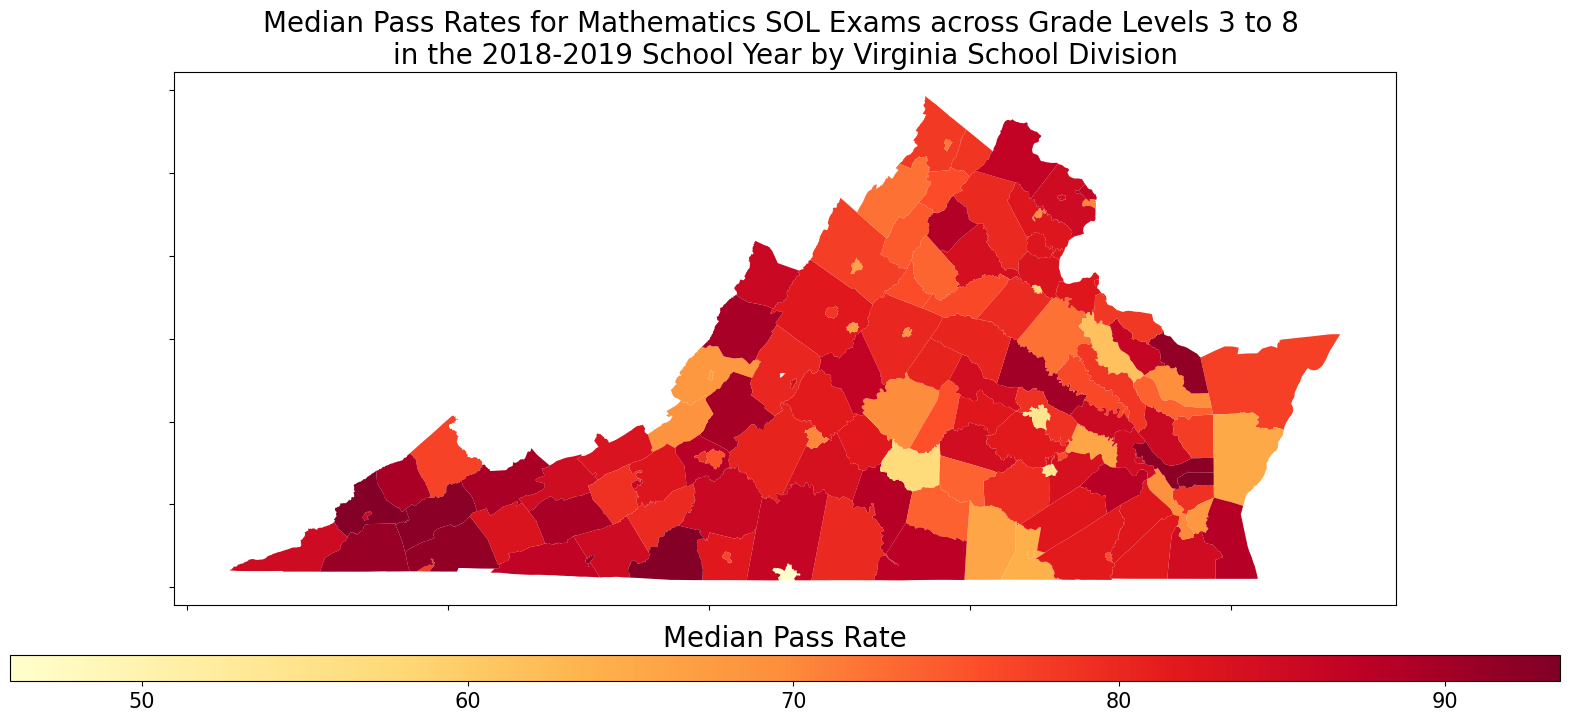

In [88]:
# place is subplot to make resizing and labeling easier
fig, ax = plt.subplots(1, 1)
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size = "5%", pad = 0.5)

# create map
math_2018_merged.plot(
    column = 'pass_rate',
    cmap = 'YlOrRd',
    ax = ax,
    legend = True,
    cax = cax,
    legend_kwds = {"orientation": "horizontal"}
)

# remove x and y axis tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])

# adjust colorbar
cb_ax = fig.axes[1] 
cb_ax.tick_params(labelsize = 15)
cb_ax.set_title("Median Pass Rate", fontsize=20)

# add title
ax.set_title('Median Pass Rates for Mathematics SOL Exams across Grade Levels 3 to 8 \nin the 2018-2019 School Year by Virginia School Division', fontsize = 20)

# adjust plot size
plt.gcf().set_size_inches(20, 20)

In [74]:
# filter dataset for engish:reading and the 2018-2019 school year
reading_2018 = data_joined_final[(data_joined_final['med_income_year'] == 2018) & (data_joined_final['subject'] == 'english:reading')]

In [75]:
# view reading_2018
reading_2018

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
6170,2018-2019,accomack county,english:reading,3,54.78,2018,43210.0
6172,2018-2019,accomack county,english:reading,4,68.98,2018,43210.0
6174,2018-2019,accomack county,english:reading,5,68.06,2018,43210.0
6176,2018-2019,accomack county,english:reading,6,69.36,2018,43210.0
6178,2018-2019,accomack county,english:reading,7,69.95,2018,43210.0
...,...,...,...,...,...,...,...
7885,2018-2019,williamsburg-james city county,english:reading,4,78.16,2018,83048.0
7887,2018-2019,williamsburg-james city county,english:reading,5,82.19,2018,83048.0
7889,2018-2019,williamsburg-james city county,english:reading,6,81.07,2018,83048.0
7891,2018-2019,williamsburg-james city county,english:reading,7,83.28,2018,83048.0


In [76]:
# view
reading_2018.info()

<class 'pandas.core.frame.DataFrame'>
Index: 792 entries, 6170 to 7893
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school_year      792 non-null    object 
 1   division_name    792 non-null    object 
 2   subject          792 non-null    object 
 3   grade_level      792 non-null    int32  
 4   pass_rate        791 non-null    float64
 5   med_income_year  792 non-null    int32  
 6   med_income       792 non-null    float64
dtypes: float64(2), int32(2), object(3)
memory usage: 43.3+ KB


In [77]:
# group by division
reading_2018 = reading_2018.groupby('division_name')['pass_rate'].median().reset_index()

In [78]:
# view reading_2018
reading_2018

,division_name,pass_rate
0,accomack county,69.170
1,albemarle county,78.265
2,alexandria city,66.595
3,alleghany county,68.180
4,amelia county,72.850
...,...,...
127,williamsburg-james city county,79.615
128,winchester city,67.240
129,wise county,85.390
130,wythe county,84.940


In [79]:
# merge the geospatial data with math pass rates
reading_2018_merged = gdf.set_index('NAME').join(reading_2018.set_index('division_name'))

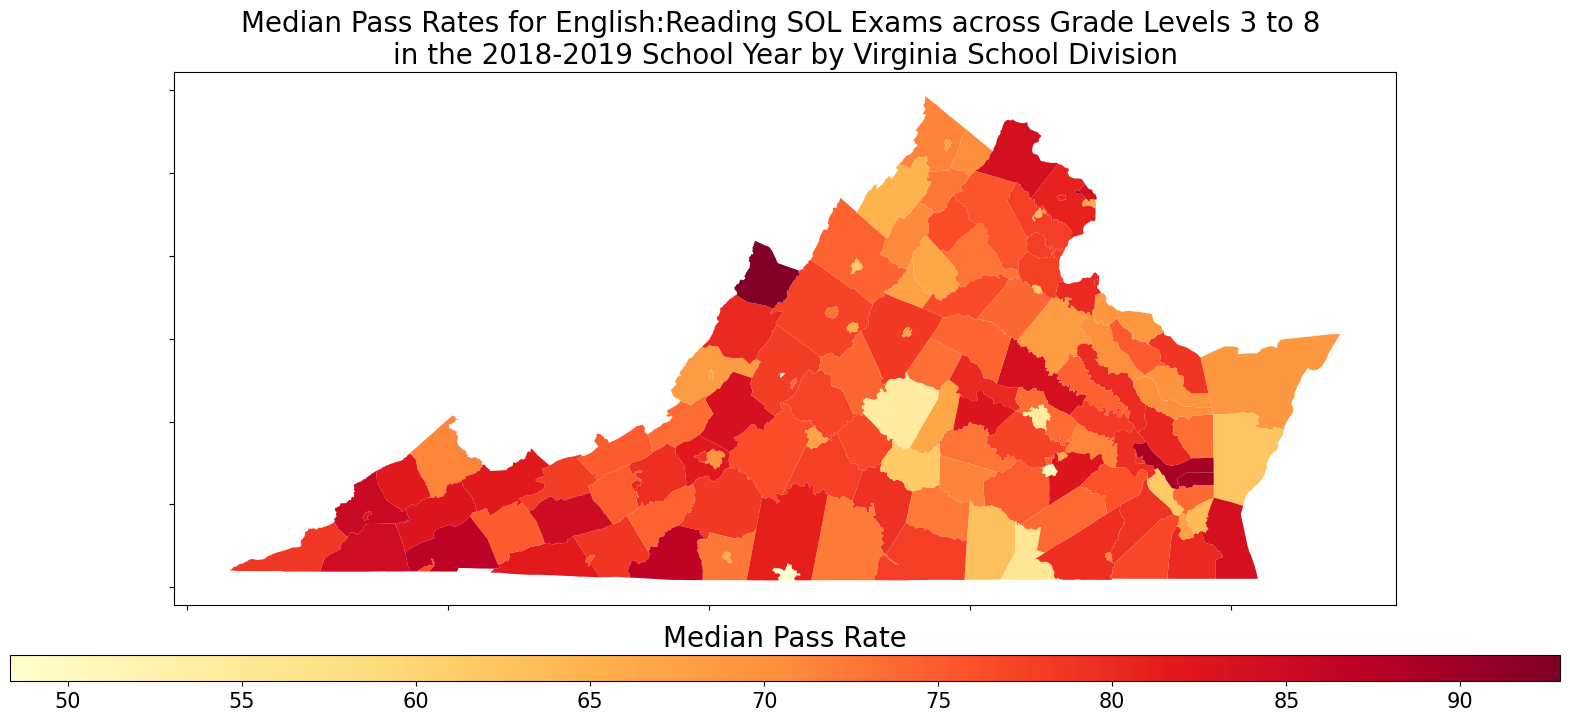

In [87]:
# place is subplot to make resizing and labeling easier
fig, ax = plt.subplots(1, 1)
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size = "5%", pad = 0.5)

# create map
reading_2018_merged.plot(
    column = 'pass_rate',
    cmap = 'YlOrRd',
    ax = ax,
    legend = True,
    cax = cax,
    legend_kwds = {"orientation":"horizontal"}
)

# remove x and y axis tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])

# adjust colorbar
cb_ax = fig.axes[1] 
cb_ax.tick_params(labelsize = 15)
cb_ax.set_title("Median Pass Rate", fontsize=20)

# add title
ax.set_title('Median Pass Rates for English:Reading SOL Exams across Grade Levels 3 to 8 \nin the 2018-2019 School Year by Virginia School Division', size = 20)

# adjust plot size
plt.gcf().set_size_inches(20, 20)

In [81]:
# filter dataset for income and the 2018-2019 school year
income_2018_mapdata = data_joined_final[(data_joined_final['med_income_year'] == 2018)]

In [82]:
income_2018_mapdata

,school_year,division_name,subject,grade_level,pass_rate,med_income_year,med_income
6170,2018-2019,accomack county,english:reading,3,54.78,2018,43210.0
6171,2018-2019,accomack county,mathematics,3,69.92,2018,43210.0
6172,2018-2019,accomack county,english:reading,4,68.98,2018,43210.0
6173,2018-2019,accomack county,mathematics,4,75.94,2018,43210.0
6174,2018-2019,accomack county,english:reading,5,68.06,2018,43210.0
...,...,...,...,...,...,...,...
7890,2018-2019,williamsburg-james city county,mathematics,6,80.95,2018,83048.0
7891,2018-2019,williamsburg-james city county,english:reading,7,83.28,2018,83048.0
7892,2018-2019,williamsburg-james city county,mathematics,7,86.58,2018,83048.0
7893,2018-2019,williamsburg-james city county,english:reading,8,77.96,2018,83048.0


In [83]:
# group by division
income_2018_mapdata = income_2018_mapdata.groupby('division_name')['med_income'].median().reset_index()

In [84]:
income_2018_mapdata

,division_name,med_income
0,accomack county,43210.0
1,albemarle county,75394.0
2,alexandria city,96733.0
3,alleghany county,47794.0
4,amelia county,58526.0
...,...,...
127,williamsburg-james city county,83048.0
128,winchester city,53797.0
129,wise county,38345.0
130,wythe county,48043.0


In [85]:
# merge the geospatial data with math pass rates
income_2018_mapdata_merged = gdf.set_index('NAME').join(income_2018_mapdata.set_index('division_name'))

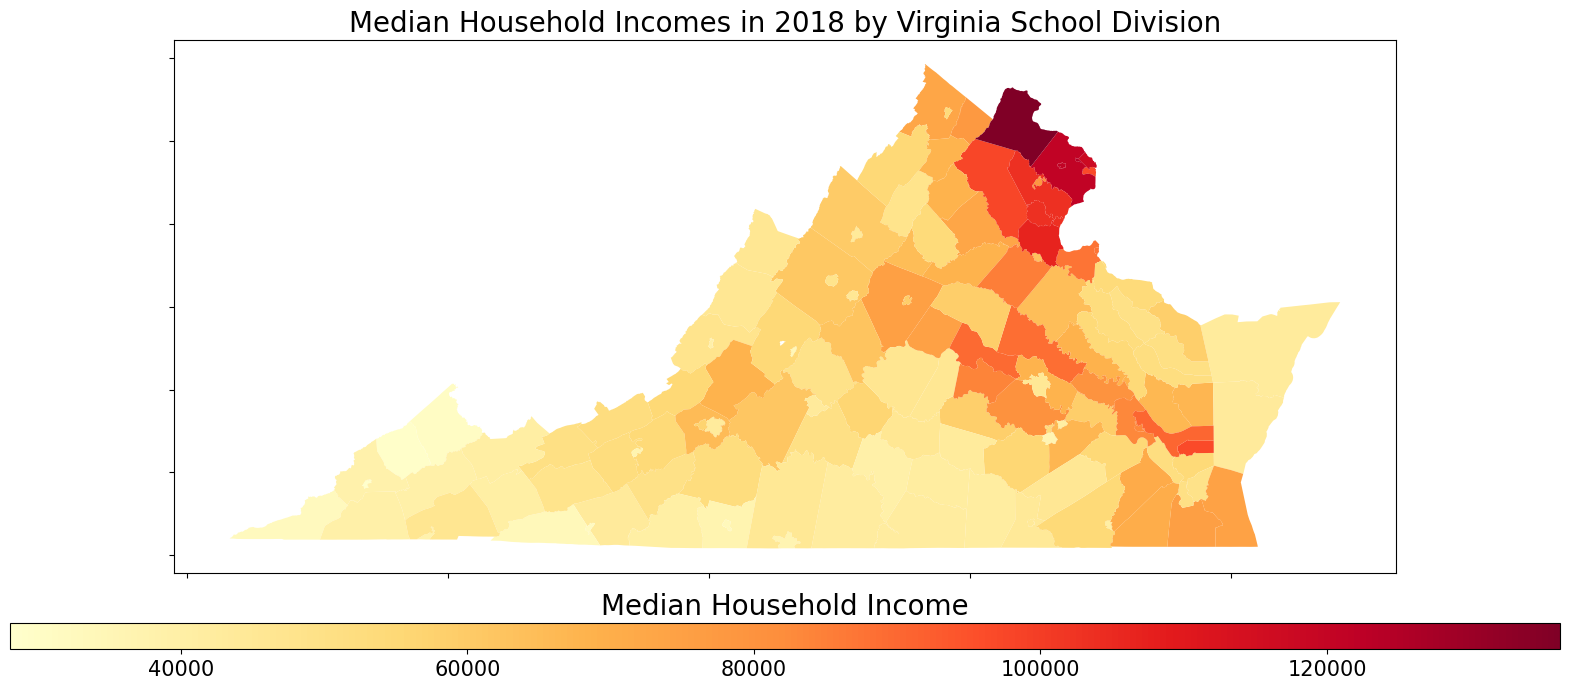

In [89]:
# # place is subplot to make resizing and labeling easier
fig, ax = plt.subplots(1, 1)
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size = "5%", pad = 0.5)

# create map
income_2018_mapdata_merged.plot(
    column = 'med_income',
    cmap = 'YlOrRd',
    ax = ax,
    legend=True,
    cax=cax,
    legend_kwds={"orientation": "horizontal"}
)

# remove x and y axis tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])

# adjust colorbar
cb_ax = fig.axes[1] 
cb_ax.tick_params(labelsize = 15)
cb_ax.set_title("Median Household Income", fontsize=20)

# add title
ax.set_title('Median Household Incomes in 2018 by Virginia School Division', size = 20)

# adjust plot size
plt.gcf().set_size_inches(20, 20)